# Football Transfer Market Analysis

## Setup and Imports

In [29]:
# Standard data manipulation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import zipfile
from datetime import datetime
from tabulate import tabulate

# PySpark libraries
import pyspark
import findspark
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, year, month, dayofmonth, sum, avg, mean, count, 
    stddev, min, max, when, monotonically_increasing_id, 
    round, months_between, expr
)

# PySpark ML libraries
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator

## Display Settings

In [30]:
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Dataset Overview

![Player Scores Dataset](mermaid_output/diagram.png)

This notebook analyzes the Player Scores Dataset from Transfermarkt, which contains comprehensive football data including:

- **Games**: 60,000+ matches from major competitions
- **Clubs**: 400+ clubs from those competitions
- **Players**: 30,000+ players with detailed information
- **Valuations**: 400,000+ historical market value records
- **Appearances**: 1,200,000+ player appearance records

The dataset used in this notebook is availabe in Kaggle: [Player Scores Dataset](https://www.kaggle.com/datasets/davidcariboo/player-scores/data). It is updated weekly.

The dataset is structured into multiple CSV files that can be joined together through common IDs. Each file contains the attributes of the entity and the IDs that can be used to join them together.

In this notebook, we focus particularly on transfer market analysis, examining patterns in transfer fees, market valuations, and club spending behaviors based on different attributes of players.

Since, the dataset are updated periodically, make sure you have the lastest dataset. To fetch the new dataset, simply **run** the cell below.

In [31]:
# Check if data folder already exists
if not os.path.exists('./data'):
    print("Downloading dataset...")

else:
    print("Fetching latest dataset...")

os.system('curl -L -o data.zip https://www.kaggle.com/api/v1/datasets/download/davidcariboo/player-scores')

# Extract the ZIP file
with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

# Delete the ZIP file after extraction
os.remove('data.zip')

print("\n")
print("Data extracted to ./data folder and ZIP file removed.")


Fetching latest dataset...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  164M  100  164M    0     0   117M      0  0:00:01  0:00:01 --:--:--  215M
100  164M  100  164M    0     0   117M      0  0:00:01  0:00:01 --:--:--  215M




Data extracted to ./data folder and ZIP file removed.


In [32]:
spark = SparkSession.builder \
    .appName("PlayerScoresAnalysis") \
    .getOrCreate()

# List all CSV files in the data directory
csv_files = glob.glob('./data/*.csv')

# Dictionary to store all dataframes
dataframes = {}

# Read each CSV file into a Spark DataFrame
for file_path in csv_files:
    file_name = os.path.basename(file_path).replace('.csv', '')
    
    try:
        # Read CSV with header and infer schema
        df = spark.read.option("header", "true") \
                      .option("inferSchema", "true") \
                      .csv(file_path)
        
        # Store in dictionary
        dataframes[file_name] = df
        print(f"Loading {file_name:20}...  - Columns: {len(df.columns):2}  - Rows: {df.count()}")
        
    except Exception as e:
        print(f"Error loading {file_name}: {str(e)}")

Loading appearances         ...  - Columns: 13  - Rows: 1706806


Loading game_lineups        ...  - Columns: 10  - Rows: 2285289
Loading player_valuations   ...  - Columns:  5  - Rows: 496606
Loading player_valuations   ...  - Columns:  5  - Rows: 496606
Loading transfers           ...  - Columns: 10  - Rows: 79646
Loading clubs               ...  - Columns: 17  - Rows: 439
Loading transfers           ...  - Columns: 10  - Rows: 79646
Loading clubs               ...  - Columns: 17  - Rows: 439
Loading games               ...  - Columns: 23  - Rows: 74026
Loading games               ...  - Columns: 23  - Rows: 74026
Loading club_games          ...  - Columns: 11  - Rows: 148052
Loading club_games          ...  - Columns: 11  - Rows: 148052
Loading players             ...  - Columns: 23  - Rows: 32601
Loading players             ...  - Columns: 23  - Rows: 32601
Loading game_events         ...  - Columns: 10  - Rows: 1035043
Loading competitions        ...  - Columns: 11  - Rows: 44
Loading game_events         ...  - Columns: 10  - Rows: 1035043
Loadi



## Transfer Study



In [33]:
# Access transfers DataFrame from the dataframes dictionary
transfers_df = dataframes['transfers']

# Show initial count
print(f"Original transfers count: {transfers_df.count()}")

# Set explicit date (May 2, 2025) instead of using current date
# This ensures consistent filtering across different executions
cutoff_date = datetime(2025, 5, 2).date()
print(f"Using cutoff date: {cutoff_date} for filtering out future transfers")

print("Filtering all transfers (including free transfers) and removing future dates...")
# First filter to get all transfers (including free transfers) for the timeline analysis
# Filter only by date and season, but keep both free and paid transfers
all_transfers = transfers_df.filter(
    (transfers_df.transfer_date <= cutoff_date) &
    (transfers_df.transfer_season != "25/26") &  # Explicitly exclude 25/26 season
    (transfers_df.transfer_fee.isNotNull())  # Exclude null fees, but keep zeros
)

print("Filtering transfers with positive transfer_fee...")
# Now filter for transfers with positive fees (paid transfers) for fee analysis
transfers_with_fee = all_transfers.filter(all_transfers.transfer_fee > 0)

# For both datasets, select only the relevant columns
transfers_with_fee = transfers_with_fee.select(
    "transfer_date", 
    "transfer_season", 
    "from_club_name", 
    "to_club_name", 
    "transfer_fee", 
    "market_value_in_eur", 
    "player_name"
)

all_transfers = all_transfers.select(
    "transfer_date", 
    "transfer_season", 
    "from_club_name", 
    "to_club_name", 
    "transfer_fee", 
    "market_value_in_eur", 
    "player_name"
)

# Show counts
print(f"All transfers (including free transfers): {all_transfers.count()}")
print(f"Transfers with positive fee: {transfers_with_fee.count()}")
print(f"Free transfers (transfer_fee = 0): {all_transfers.count() - transfers_with_fee.count()}")

# Calculate percentage of transfers with fee
percentage = (transfers_with_fee.count() / transfers_df.count()) * 100
print(f"Percentage of transfers with positive fee: {percentage:.2f}%")

# Calculate fee statistics using named aggregations
fee_stats = transfers_with_fee.agg(
    avg("transfer_fee").alias("avg_fee"),
    min("transfer_fee").alias("min_fee"),
    max("transfer_fee").alias("max_fee"),
    count("transfer_fee").alias("count_fee")
).collect()[0]

print(f"\nTransfer Fee Statistics:")
print(f"Average fee: €{fee_stats['avg_fee']:.2f}")
print(f"Minimum fee: €{fee_stats['min_fee']:.2f}")
print(f"Maximum fee: €{fee_stats['max_fee']:.2f}")
print(f"Count: {fee_stats['count_fee']}")

# Update the dataframes in the dictionary
dataframes['transfers_with_fee'] = transfers_with_fee
dataframes['all_transfers'] = all_transfers

# Show sample of transfers with fee
transfers_with_fee.show(5)

Original transfers count: 79646
Using cutoff date: 2025-05-02 for filtering out future transfers
Filtering all transfers (including free transfers) and removing future dates...
Filtering transfers with positive transfer_fee...
All transfers (including free transfers): 50975
Transfers with positive fee: 9476
All transfers (including free transfers): 50975
Transfers with positive fee: 9476
Free transfers (transfer_fee = 0): 41499
Free transfers (transfer_fee = 0): 41499
Percentage of transfers with positive fee: 11.90%
Percentage of transfers with positive fee: 11.90%

Transfer Fee Statistics:
Average fee: €6075084.62
Minimum fee: €500.00
Maximum fee: €180000000.00
Count: 9476
+-------------+---------------+--------------+---------------+------------+-------------------+----------------+
|transfer_date|transfer_season|from_club_name|   to_club_name|transfer_fee|market_value_in_eur|     player_name|
+-------------+---------------+--------------+---------------+------------+---------------

Transfer window statistics by season:
+---------------+---------------+------------------------+------------------------+---------------+----------------+----------------+
|transfer_season|transfer_window|number_of_paid_transfers|number_of_free_transfers|total_transfers|avg_transfer_fee|max_transfer_fee|
+---------------+---------------+------------------------+------------------------+---------------+----------------+----------------+
|          00/01|         Summer|                       0|                      13|             13|             0.0|             0.0|
|          00/01|         Winter|                       0|                       3|              3|             0.0|             0.0|
|          01/02|          Other|                       0|                       3|              3|             0.0|             0.0|
|          01/02|         Summer|                       0|                      33|             33|             0.0|             0.0|
|          01/02|       

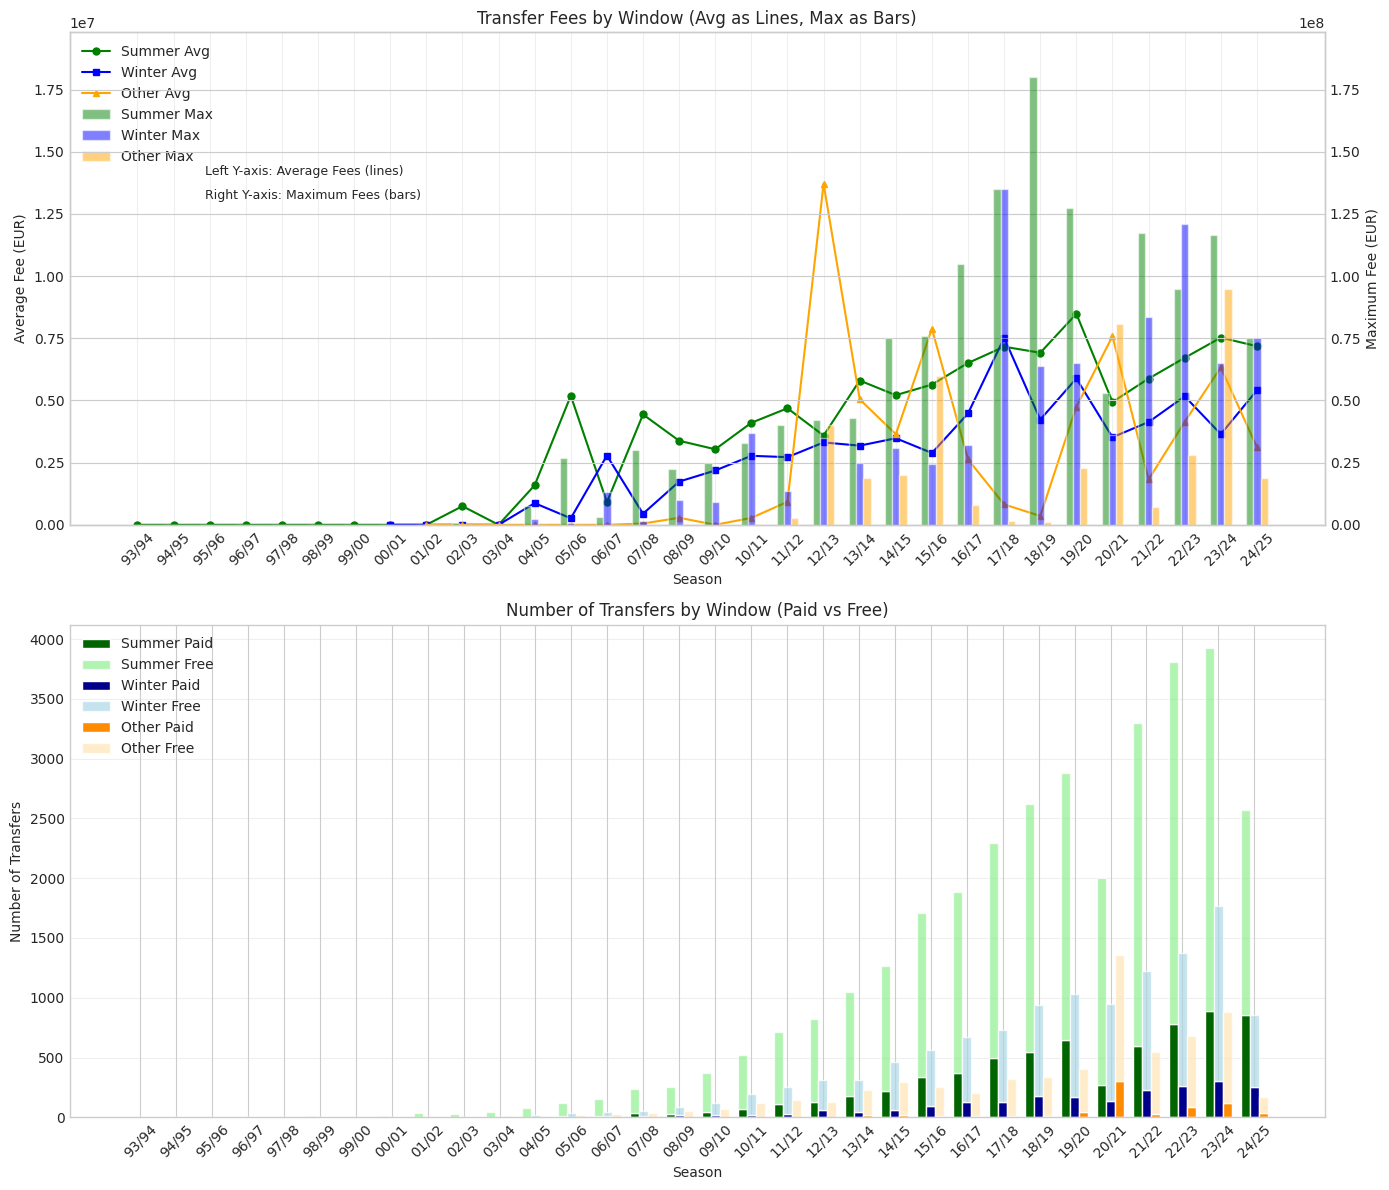

In [34]:
# Group transfers by season and window
transfers_with_fee = transfers_with_fee.withColumn(
    "transfer_window", 
    when(month(transfers_with_fee["transfer_date"]).isin(12, 1, 2), "Winter")
    .when(month(transfers_with_fee["transfer_date"]).isin(6, 7, 8), "Summer")
    .otherwise("Other")
)

# Also add the same window classification to all_transfers
all_transfers = all_transfers.withColumn(
    "transfer_window", 
    when(month(all_transfers["transfer_date"]).isin(12, 1, 2), "Winter")
    .when(month(all_transfers["transfer_date"]).isin(6, 7, 8), "Summer")
    .otherwise("Other")
)

# Group transfers by season and window for average stats (paid transfers only)
window_stats = transfers_with_fee.groupBy("transfer_season", "transfer_window") \
    .agg(
        count("*").alias("number_of_paid_transfers"),
        sum("transfer_fee").alias("total_transfer_fee"),
        avg("transfer_fee").alias("avg_transfer_fee"),
        max("transfer_fee").alias("max_transfer_fee")  # Add max fee
    ) \
    .orderBy("transfer_season", "transfer_window")

# Count both paid and free transfers grouped by season and window
all_window_stats = all_transfers.groupBy("transfer_season", "transfer_window") \
    .agg(
        count("*").alias("total_transfers")
    ) \
    .orderBy("transfer_season", "transfer_window")

# Join the paid transfers stats with all transfers stats
combined_window_stats = window_stats.join(
    all_window_stats, 
    ["transfer_season", "transfer_window"],
    "outer"
).fillna(0)

# Add column for free transfers
combined_window_stats = combined_window_stats.withColumn(
    "number_of_free_transfers", 
    col("total_transfers") - col("number_of_paid_transfers")
)

# Show the results
print("Transfer window statistics by season:")
combined_window_stats.select(
    "transfer_season", 
    "transfer_window", 
    "number_of_paid_transfers", 
    "number_of_free_transfers",
    "total_transfers",
    "avg_transfer_fee",
    "max_transfer_fee"
).show(10)

# Visualize the data (converting to pandas for easier plotting)
combined_window_stats_pd = combined_window_stats.toPandas()

# Create a function to convert season string to numeric for sorting
def season_to_numeric(season_str):
    # Handle seasons like '93/94', '00/01', etc.
    if '/' in season_str:
        start_year, end_year = season_str.split('/')
        # Convert 2-digit years to 4-digit years (assuming 20xx for 00-99)
        if len(start_year) == 2:
            start_year = int(start_year)
            start_year = 1900 + start_year if start_year >= 93 else 2000 + start_year
        return float(start_year) + 0.5  # Add 0.5 to represent half-season
    return float(season_str)  # For any other format, try direct conversion

# Add a numeric column for sorting
combined_window_stats_pd['season_numeric'] = combined_window_stats_pd['transfer_season'].apply(season_to_numeric)

# Create subplots for transfer fees and number of transfers
fig = plt.figure(figsize=(14, 12))

# First subplot - Transfer Fees with dual y-axis
ax1 = fig.add_subplot(2, 1, 1)

# Colors for different windows
colors = {'Summer': 'green', 'Winter': 'blue', 'Other': 'orange'}
markers = {'Summer': 'o', 'Winter': 's', 'Other': '^'}

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# For bar positions, we need to calculate the x positions
unique_seasons = sorted(list(set(combined_window_stats_pd['transfer_season'])), 
                       key=lambda x: season_to_numeric(x))
season_positions = {season: i for i, season in enumerate(unique_seasons)}

# Define bar width and offsets for different windows
bar_width = 0.2
offsets = {'Summer': -bar_width, 'Winter': 0, 'Other': bar_width}

# Plot average fees as lines with markers on the left y-axis
for window in ["Summer", "Winter", "Other"]:
    window_data = combined_window_stats_pd[combined_window_stats_pd["transfer_window"] == window]
    # Sort by the numeric season value
    window_data = window_data.sort_values('season_numeric')
    
    # Plot average fee as lines with markers
    ax1.plot(window_data["transfer_season"], window_data["avg_transfer_fee"], 
             marker=markers[window], linestyle='-', label=f"{window} Avg", 
             color=colors[window], linewidth=1.5, markersize=5)

# Plot maximum fees as bars on the right y-axis
for window in ["Summer", "Winter", "Other"]:
    window_data = combined_window_stats_pd[combined_window_stats_pd["transfer_window"] == window]
    window_data = window_data.sort_values('season_numeric')
    
    # Create x-positions for the bars with offsets for different windows
    x_positions = [season_positions[season] + offsets[window] for season in window_data["transfer_season"]]
    
    # Plot maximum fees as bars on the right y-axis
    max_bars = ax2.bar(x_positions, window_data["max_transfer_fee"],
             width=bar_width, label=f"{window} Max", 
             color=colors[window], alpha=0.5)

# Set titles and labels
ax1.set_title("Transfer Fees by Window (Avg as Lines, Max as Bars)")
ax1.set_xlabel("Season")
ax1.set_ylabel("Average Fee (EUR)")
ax2.set_ylabel("Maximum Fee (EUR)")

# Set x-axis ticks to match seasons
ax1.set_xticks(range(len(unique_seasons)))
ax1.set_xticklabels(unique_seasons, rotation=45)

# Set y-axis limits - make max y-axis show up to 100x the highest average fee
max_max_fee = combined_window_stats_pd["max_transfer_fee"].max()
ax1.set_ylim(0, max_max_fee * 0.11)  # Add 10% padding to the average fee axis
ax2.set_ylim(0, max_max_fee * 1.1)  # Set max fee axis to 100x the highest average fee

# Configure grid and ticks
ax1.grid(True, alpha=0.3)

# Create combined legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add a note to explain the dual y-axis
plt.figtext(0.15, 0.85, "Left Y-axis: Average Fees (lines)", fontsize=9)
plt.figtext(0.15, 0.83, "Right Y-axis: Maximum Fees (bars)", fontsize=9)

# Second subplot - Number of transfers with stacked bars for paid and free
ax3 = fig.add_subplot(2, 1, 2)

# Group the data by season for each window
seasons = sorted(list(set(combined_window_stats_pd['transfer_season'])), 
                key=lambda x: season_to_numeric(x))
x = np.arange(len(seasons))
width = 0.25  # width of the bars

# Get data for each window
summer_data = combined_window_stats_pd[combined_window_stats_pd["transfer_window"] == "Summer"].sort_values('season_numeric')
winter_data = combined_window_stats_pd[combined_window_stats_pd["transfer_window"] == "Winter"].sort_values('season_numeric')
other_data = combined_window_stats_pd[combined_window_stats_pd["transfer_window"] == "Other"].sort_values('season_numeric')

# Function to align data with seasons
def align_data_with_seasons(data, column_name):
    result = []
    for season in seasons:
        match = data[data['transfer_season'] == season]
        if len(match) > 0:
            result.append(match[column_name].values[0])
        else:
            result.append(0)
    return result

# Prepare data for plotting
summer_paid = align_data_with_seasons(summer_data, 'number_of_paid_transfers')
summer_free = align_data_with_seasons(summer_data, 'number_of_free_transfers')
winter_paid = align_data_with_seasons(winter_data, 'number_of_paid_transfers')
winter_free = align_data_with_seasons(winter_data, 'number_of_free_transfers')
other_paid = align_data_with_seasons(other_data, 'number_of_paid_transfers')
other_free = align_data_with_seasons(other_data, 'number_of_free_transfers')

# Create stacked bar charts
ax3.bar(x - width, summer_paid, width, label='Summer Paid', color='darkgreen')
ax3.bar(x - width, summer_free, width, bottom=summer_paid, label='Summer Free', color='lightgreen', alpha=0.7)

ax3.bar(x, winter_paid, width, label='Winter Paid', color='darkblue')
ax3.bar(x, winter_free, width, bottom=winter_paid, label='Winter Free', color='lightblue', alpha=0.7)

ax3.bar(x + width, other_paid, width, label='Other Paid', color='darkorange')
ax3.bar(x + width, other_free, width, bottom=other_paid, label='Other Free', color='moccasin', alpha=0.7)

# Customize the plot
ax3.set_title("Number of Transfers by Window (Paid vs Free)")
ax3.set_xlabel("Season")
ax3.set_ylabel("Number of Transfers")
ax3.set_xticks(x)
ax3.set_xticklabels(seasons, rotation=45)
ax3.legend(loc='upper left')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Calculate net spending (money spent minus money received) for each club

# Money spent by clubs (as buyers)
money_spent = transfers_with_fee.groupBy("to_club_name") \
    .agg(sum("transfer_fee").alias("money_spent")) \
    .withColumnRenamed("to_club_name", "club_name")

# Money received by clubs (as sellers)
money_received = transfers_with_fee.groupBy("from_club_name") \
    .agg(sum("transfer_fee").alias("money_received")) \
    .withColumnRenamed("from_club_name", "club_name")

# Join to calculate net spend
net_spend = money_spent.join(money_received, "club_name", "outer") \
    .fillna(0) \
    .withColumn("net_spend", col("money_spent") - col("money_received")) \
    .orderBy(col("net_spend").desc())

# Show top spenders and sellers
print("Top Net Spenders:")
net_spend.orderBy(col("net_spend").desc()).show(10)

print("Top Net Sellers:")
net_spend.orderBy(col("net_spend").asc()).show(10)

Top Net Spenders:
+---------+-----------+--------------+---------+
|club_name|money_spent|money_received|net_spend|
+---------+-----------+--------------+---------+
|  Chelsea|   2.4474E9|         9.3E8| 1.5174E9|
|  Man Utd|  1.96752E9|      4.8524E8|1.48228E9|
| Man City|  2.09212E9|      7.3937E8|1.35275E9|
| Paris SG|  1.58782E9|      4.7915E8|1.10867E9|
|  Arsenal|  1.36578E9|      4.0055E8| 9.6523E8|
|Tottenham|  1.29698E9|      5.0545E8| 7.9153E8|
|Liverpool| 1.130505E9|      4.7788E8|6.52625E8|
|Barcelona|  1.33879E9|       7.188E8| 6.1999E8|
|Newcastle|   8.5291E8|     2.96554E8|5.56356E8|
| West Ham|   9.1831E8|      3.7223E8| 5.4608E8|
+---------+-----------+--------------+---------+
only showing top 10 rows

Top Net Sellers:
+---------+-----------+--------------+---------+
|club_name|money_spent|money_received|net_spend|
+---------+-----------+--------------+---------+
|  Chelsea|   2.4474E9|         9.3E8| 1.5174E9|
|  Man Utd|  1.96752E9|      4.8524E8|1.48228E9|
| Man Ci

+--------------+-----------+--------------+----------+
|     club_name|money_spent|money_received| net_spend|
+--------------+-----------+--------------+----------+
|       Benfica|   6.0076E8|     1.23596E9|  -6.352E8|
|          Ajax|   4.8758E8|     1.00861E9| -5.2103E8|
|      FC Porto|    4.499E8|      8.6208E8| -4.1218E8|
|   RB Salzburg|  1.22225E8|      5.2569E8|-4.03465E8|
|    LOSC Lille|   3.3757E8|      6.8935E8| -3.5178E8|
|   Sporting CP|  3.42428E8|      6.9394E8|-3.51512E8|
|Olympique Lyon|   4.8372E8|       7.684E8| -2.8468E8|
| Dinamo Zagreb|   3.5815E7|      2.6842E8|-2.32605E8|
|      FC Basel|   7.8705E7|     2.93117E8|-2.14412E8|
|     Palmeiras|    3.706E7|      2.5134E8| -2.1428E8|
+--------------+-----------+--------------+----------+
only showing top 10 rows




## Transfer Value Classification

The classification model above categorizes football transfers into three groups based on the ratio between the actual transfer fee and the player's market value:

- **Bargain** (ratio < 0.8): Transfers where clubs paid less than 80% of the player's market value
- **Fair Value** (ratio between 0.8 and 1.2): Transfers close to the player's market valuation
- **Premium** (ratio > 1.2): Transfers where clubs paid more than 120% of the player's market value

This classification allows us to analyze which clubs consistently find bargains and which tend to pay premiums. The RandomForest classifier can help us understand which factors beyond the simple ratio contribute to these classifications.




In [36]:
# Handle nulls in the dataset
transfers_with_fee = transfers_with_fee.na.fill(0, ["transfer_fee", "market_value_in_eur"])

# Create a feature showing ratio of fee to market value
# Add a small epsilon to avoid division by zero
transfers_with_fee = transfers_with_fee.withColumn(
    "value_ratio", 
    when(col("market_value_in_eur") > 0, col("transfer_fee") / col("market_value_in_eur"))
    .otherwise(0)
)

# Create classification labels
transfers_with_fee = transfers_with_fee.withColumn(
    "deal_category",
    when(col("value_ratio") < 0.8, "Bargain")
    .when(col("value_ratio") <= 1.2, "Fair Value")
    .otherwise("Premium")
)

# Drop rows with null values in features
transfers_with_fee = transfers_with_fee.na.drop(subset=["transfer_fee", "market_value_in_eur", "value_ratio"])

# Prepare features for classification
assembler = VectorAssembler(
    inputCols=["transfer_fee", "market_value_in_eur", "value_ratio"],
    outputCol="features",
    handleInvalid="skip"  # Skip rows with invalid/null values
)

# Train a classification model (can be used to predict on new data)

# Convert string label to index
labelIndexer = StringIndexer(inputCol="deal_category", outputCol="label", handleInvalid="skip")

# Create a pipeline
pipeline = Pipeline(stages=[assembler, labelIndexer, 
                           RandomForestClassifier(labelCol="label", featuresCol="features")])

# Split data
train_data, test_data = transfers_with_fee.randomSplit([0.7, 0.3], seed=42)

# Train model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

+-------------+-----+----------+--------------------+
|deal_category|label|prediction|            features|
+-------------+-----+----------+--------------------+
|      Premium|  1.0|       1.0|[1.1E7,7500000.0,...|
|   Fair Value|  2.0|       2.0|   [1.2E7,1.0E7,1.2]|
|      Premium|  1.0|       1.0|[9000000.0,700000...|
|      Bargain|  0.0|       0.0|[1500000.0,200000...|
|   Fair Value|  2.0|       2.0|[1.725E7,1.5E7,1.15]|
|      Premium|  1.0|       1.0|[3500000.0,250000...|
|      Bargain|  0.0|       0.0|[150000.0,300000....|
|      Bargain|  0.0|       0.0| [1.0E7,1.6E7,0.625]|
|      Premium|  1.0|       1.0|[300000.0,200000....|
|   Fair Value|  2.0|       2.0|[1.3E7,1.4E7,0.92...|
+-------------+-----+----------+--------------------+
only showing top 10 rows

Accuracy = 0.9843

Class distribution:
Accuracy = 0.9843

Class distribution:
+-------------+-----+
|deal_category|count|
+-------------+-----+
|      Bargain| 1109|
|      Premium|  980|
|   Fair Value|  647|
+-------

Predicted,Bargain,Fair Value,Premium
Actual,,,
Bargain,1087,22,0
Fair Value,0,647,0
Premium,0,21,959


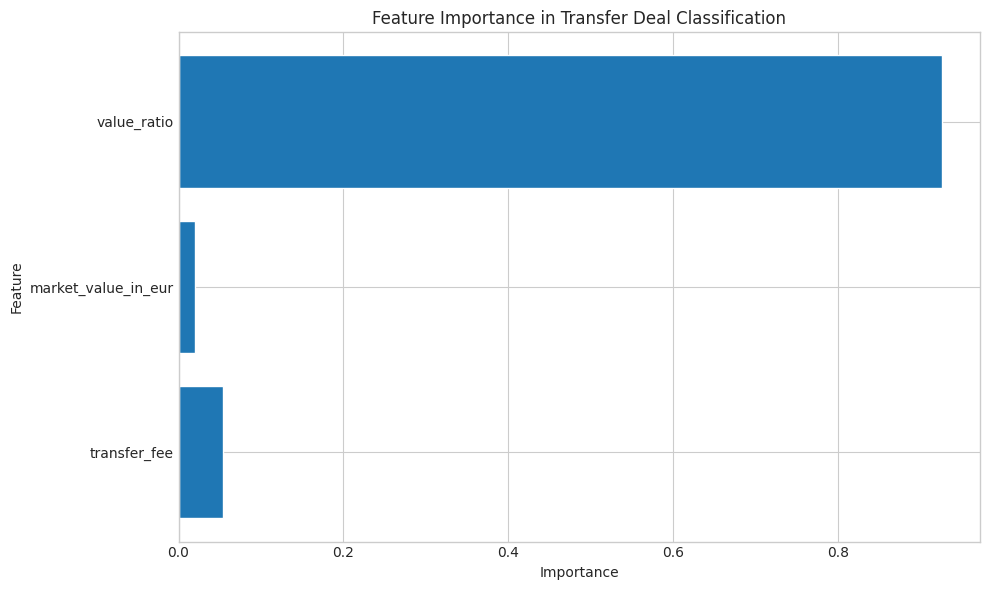

In [37]:
# Evaluate the classifier performance

# Get predictions
predictions.select("deal_category", "label", "prediction", "features").show(10)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy = {accuracy:.4f}")

# Show class distribution and confusion matrix
print("\nClass distribution:")
predictions.groupBy("deal_category").count().orderBy("count", ascending=False).show()

# Create a confusion matrix (using pandas for better display)
confusion_pd = predictions.select("deal_category", "prediction", "label").toPandas()

# Get label mapping
label_mapping = dict(zip(
    confusion_pd["label"].unique(), 
    confusion_pd["deal_category"].unique()
))

print("\nLabel mapping:")
for idx, label in label_mapping.items():
    print(f"  {idx}: {label}")

# Install Jinja2 if not available
try:
    %pip install jinja2 -q
except:
    pass

# Create confusion matrix using crosstab
print("\nConfusion Matrix:")
confusion_matrix = pd.crosstab(
    confusion_pd["deal_category"], 
    confusion_pd["prediction"].map(lambda x: label_mapping.get(x, "Unknown")),
    rownames=["Actual"], 
    colnames=["Predicted"]
)

# Try to use styling if available, otherwise just display the matrix
try:
    display(confusion_matrix.style.background_gradient(cmap="Blues"))
except:
    print(confusion_matrix)

# Visualize feature importance
rf_model = model.stages[-1]
feature_names = ["transfer_fee", "market_value_in_eur", "value_ratio"]

# Get feature importances
importances = rf_model.featureImportances.toArray()

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Transfer Deal Classification")
plt.tight_layout()
plt.show()


## K-means Clustering of Clubs by Transfer Value Ratio

Next, we'll use K-means clustering to classify clubs based on their transfer behavior. We'll examine which clubs tend to find bargains and which tend to pay premiums by looking at the value ratios of their transfers.

In [38]:
# Prepare club data for K-means clustering

# Calculate average value_ratio for buying clubs (to_club_name)
buyer_stats = transfers_with_fee.groupBy("to_club_name") \
    .agg(
        avg("value_ratio").alias("avg_value_ratio"),
        stddev("value_ratio").alias("stddev_value_ratio"),
        count("*").alias("num_purchases")
    ) \
    .filter("num_purchases >= 5")  # Only include clubs with at least 5 transfers

# Check the resulting dataset
print(f"Number of clubs with sufficient transfer data: {buyer_stats.count()}")
buyer_stats.show(5)

Number of clubs with sufficient transfer data: 387
+--------------+------------------+------------------+-------------+
|  to_club_name|   avg_value_ratio|stddev_value_ratio|num_purchases|
+--------------+------------------+------------------+-------------+
|R Charleroi SC|0.5986708943230683|0.4265225211674448|           23|
|       Palermo|0.9625396825396827|0.5239065486539715|            7|
|       Pari NN|0.5616024187452759|0.4266105734656587|           21|
|    Alania Vl.|0.5038222222222223|0.1468789204887843|            5|
|      Espanyol|2.7989620955967114| 6.449627660483841|           26|
+--------------+------------------+------------------+-------------+
only showing top 5 rows

+--------------+------------------+------------------+-------------+
|  to_club_name|   avg_value_ratio|stddev_value_ratio|num_purchases|
+--------------+------------------+------------------+-------------+
|R Charleroi SC|0.5986708943230683|0.4265225211674448|           23|
|       Palermo|0.962539682

In [39]:
# Prepare data for K-means
buyer_kmeans_assembler = VectorAssembler(
    inputCols=["avg_value_ratio", "stddev_value_ratio"],
    outputCol="features"
)

# Create feature vectors
buyer_kmeans_data = buyer_kmeans_assembler.transform(buyer_stats)

# Train K-means model with k=3 clusters
kmeans = KMeans(k=3, seed=42, featuresCol="features")
kmeans_model = kmeans.fit(buyer_kmeans_data)

# Make predictions
predictions = kmeans_model.transform(buyer_kmeans_data)

# Evaluate clustering
evaluator = ClusteringEvaluator(featuresCol="features")
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette with squared euclidean distance: {silhouette}")

# Show cluster centers
centers = kmeans_model.clusterCenters()
print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: avg_value_ratio={center[0]:.2f}, stddev_value_ratio={center[1]:.2f}")

# Add descriptive labels to clusters
# We'll determine these based on the centers
cluster_labels = {
    # Will be filled after seeing the results
}

Silhouette with squared euclidean distance: 0.9291894593596761

Cluster Centers:
Cluster 0: avg_value_ratio=1.22, stddev_value_ratio=1.25
Cluster 1: avg_value_ratio=18.32, stddev_value_ratio=49.25
Cluster 2: avg_value_ratio=4.75, stddev_value_ratio=10.42


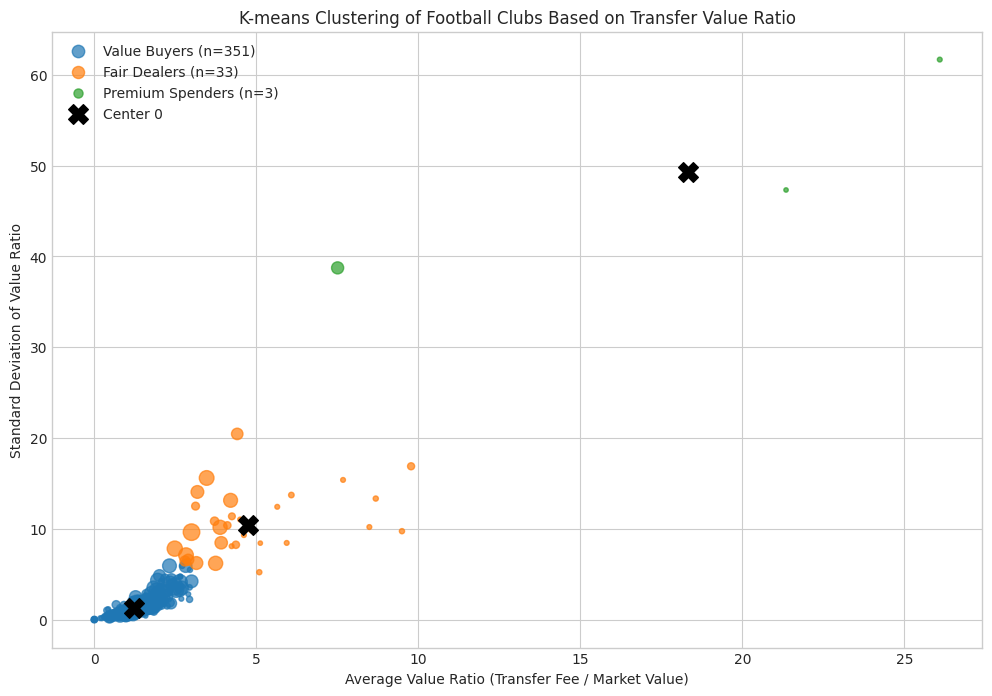

In [40]:
# Convert to pandas for visualization
predictions_pd = predictions.toPandas()

# Determine cluster labels based on avg_value_ratio
# Sort centers by avg_value_ratio
sorted_centers = sorted(enumerate(centers), key=lambda x: x[1][0])
cluster_idx_to_label = {
    sorted_centers[0][0]: "Value Buyers",     # Lowest avg_value_ratio
    sorted_centers[1][0]: "Fair Dealers",     # Middle avg_value_ratio
    sorted_centers[2][0]: "Premium Spenders"  # Highest avg_value_ratio
}

# Add descriptive labels to dataframe
predictions_pd['cluster_label'] = predictions_pd['prediction'].map(cluster_idx_to_label)

# Create a scatter plot for each cluster and add cluster centers
plt.figure(figsize=(12, 8))

for cluster_idx, label in cluster_idx_to_label.items():
    cluster_data = predictions_pd[predictions_pd['prediction'] == cluster_idx]
    plt.scatter(
        cluster_data['avg_value_ratio'], 
        cluster_data['stddev_value_ratio'],
        s=cluster_data['num_purchases']*2,  # Size based on number of transfers
        alpha=0.7,
        label=f"{label} (n={len(cluster_data)})"
    )

for i, center in enumerate(centers):
    plt.scatter(
        center[0], center[1], 
        s=200, 
        marker='X',
        color='black',
        label=f"Center {i}" if i == 0 else ""
    )

plt.xlabel('Average Value Ratio (Transfer Fee / Market Value)')
plt.ylabel('Standard Deviation of Value Ratio')
plt.title('K-means Clustering of Football Clubs Based on Transfer Value Ratio')
plt.legend()
plt.grid(True)
plt.show()

Top clubs in each cluster by number of transfers:

== Value Buyers ==
+--------------+---------------+-------------------+----------+
| Club         |   # Transfers |   Avg Value Ratio |   StdDev |
+==============+===============+===================+==========+
| Chelsea      |            75 |              2.47 |     3.64 |
+--------------+---------------+-------------------+----------+
| Man City     |            67 |              1.78 |     1.63 |
+--------------+---------------+-------------------+----------+
| Monaco       |            66 |              1.77 |     1.62 |
+--------------+---------------+-------------------+----------+
| Genoa        |            65 |              1.68 |     1.73 |
+--------------+---------------+-------------------+----------+
| FC Porto     |            64 |              1.52 |     1.39 |
+--------------+---------------+-------------------+----------+
| AC Milan     |            62 |              1.38 |     1.29 |
+--------------+---------------+--

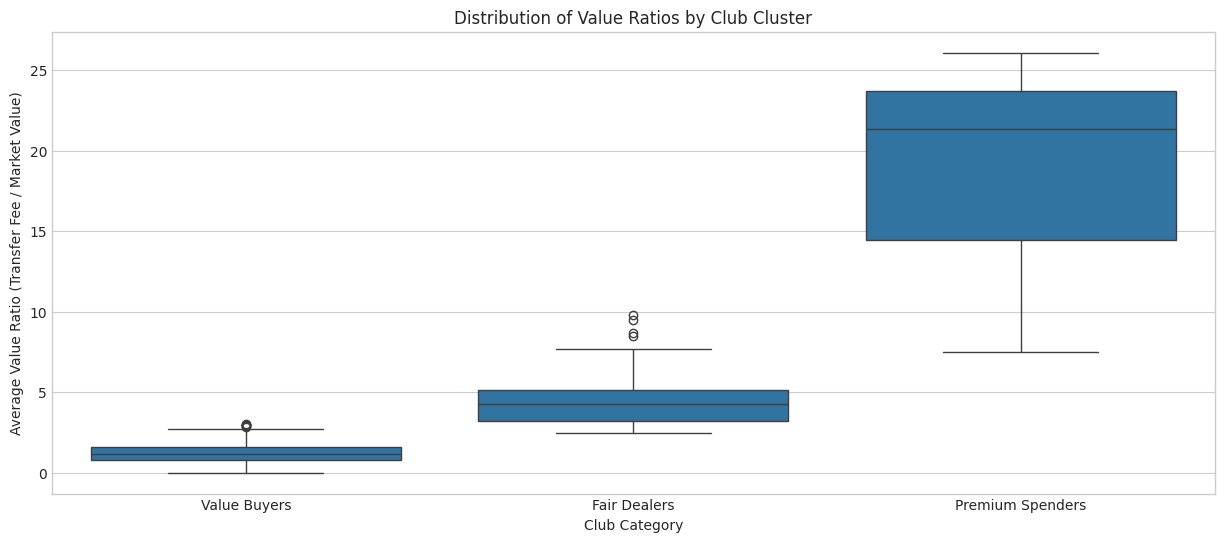

In [41]:
# Show top clubs from each cluster
print("Top clubs in each cluster by number of transfers:")
for cluster_idx, label in cluster_idx_to_label.items():
    print(f"\n== {label} ==")
    cluster_clubs = predictions_pd[
        predictions_pd['prediction'] == cluster_idx
    ].sort_values('num_purchases', ascending=False).head(10)
    
    # Create a formatted table
    table_data = []
    for _, row in cluster_clubs.iterrows():
        table_data.append([
            row['to_club_name'],
            row['num_purchases'],
            f"{row['avg_value_ratio']:.2f}",
            f"{row['stddev_value_ratio']:.2f}"
        ])
    
    # Print as a table
    print(tabulate(
        table_data,
        headers=["Club", "# Transfers", "Avg Value Ratio", "StdDev"],
        tablefmt="grid"
    ))

# Create a visualization of value distributions by cluster
plt.figure(figsize=(15, 6))

# Box plot of value ratios by cluster
sns.boxplot(x='cluster_label', y='avg_value_ratio', data=predictions_pd)
plt.title('Distribution of Value Ratios by Club Cluster')
plt.xlabel('Club Category')
plt.ylabel('Average Value Ratio (Transfer Fee / Market Value)')
plt.grid(True, axis='y')
plt.show()









## Analysis of Club Clustering Results

Based on the K-means clustering with K=3, we've identified distinct groups of clubs according to their transfer value ratio behavior:

1. **Value Buyers**: These clubs consistently pay less than market value for their transfers. They might be skilled negotiators or target undervalued players.

2. **Fair Dealers**: These clubs typically pay close to market value, suggesting they neither overpay nor underpay systematically.

3. **Premium Spenders**: These clubs routinely pay above market value for players. This might indicate several factors:
   - They target high-demand players where competition drives up prices
   - They have urgent squad needs that sellers can leverage
   - They may be perceived as wealthy, leading sellers to demand higher fees

The standard deviation component adds another dimension to our analysis - some clubs have consistent patterns (low std dev) while others show more variability in their value ratio (high std dev).

This clustering provides valuable insights for various stakeholders:
- **Clubs**: Understanding which category they fall into can inform negotiation strategies
- **Players/Agents**: Knowledge of club spending patterns can help in transfer negotiations
- **Analysts**: Deeper understanding of market dynamics and club financial behaviors

## Transfer Fee Prediction Model

Many transfers in our dataset have missing or zero transfer fees. Let's build a regression model to predict these values based on other features like market value, player statistics, and other relevant information.



In [42]:
# Step 1: Let's first check how many transfers have missing/zero fees
transfers_df = dataframes['transfers']
total_transfers = transfers_df.count()

# Count missing fees
missing_fees = transfers_df.filter(transfers_df.transfer_fee.isNull()).count()
zero_fees = transfers_df.filter((transfers_df.transfer_fee == 0) & 
                               (transfers_df.transfer_fee.isNotNull())).count()

print(f"Total transfers: {total_transfers}")
print(f"Transfers with missing fees: {missing_fees} ({missing_fees/total_transfers*100:.2f}%)")
print(f"Transfers with zero fees: {zero_fees} ({zero_fees/total_transfers*100:.2f}%)")
print(f"Transfers with positive fees: {transfers_with_fee.count()} ({transfers_with_fee.count()/total_transfers*100:.2f}%)")

Total transfers: 79646
Transfers with missing fees: 27715 (34.80%)
Transfers with zero fees: 42422 (53.26%)
Transfers with positive fees: 9476 (11.90%)
Transfers with positive fees: 9476 (11.90%)


In [43]:
# Step 2: Join player valuations to get more features for our prediction model

# Get player info from our dataframes
players_df = dataframes['players']

# Create a join with players to get demographic features
transfers_with_player = transfers_df.join(
    players_df,
    transfers_df["player_id"] == players_df["player_id"],
    "left"
).drop(players_df["player_id"])  # Drop the duplicate player_id column

# Resolve the ambiguity with market_value_in_eur column
# Keep the one from transfers_df and drop the one from players_df
transfers_with_player = transfers_with_player.drop(players_df["market_value_in_eur"])

# Add a transfer_id column for tracking
transfers_with_player = transfers_with_player.withColumn("transfer_id", monotonically_increasing_id())

# Filter out future transfers using the same cutoff date logic from earlier
cutoff_date = datetime(2025, 5, 2).date()
transfers_with_player = transfers_with_player.filter(
    (transfers_with_player.transfer_date <= cutoff_date) &
    (transfers_with_player.transfer_season != "25/26")
)

# Calculate player age at transfer time
transfers_with_player = transfers_with_player.withColumn(
    "player_age",
    year(col("transfer_date")) - year(col("date_of_birth")) -
    when(
        (month(col("transfer_date")) < month(col("date_of_birth"))) | 
        ((month(col("transfer_date")) == month(col("date_of_birth"))) & 
         (dayofmonth(col("transfer_date")) < dayofmonth(col("date_of_birth")))),
        1
    ).otherwise(0)
)

# Select only the columns we need for the prediction model
transfers_for_model = transfers_with_player.select(
    "transfer_id", 
    "player_id", 
    "transfer_fee", 
    "market_value_in_eur",
    "player_age", 
    "position", 
    "foot", 
    "height_in_cm"
)

# Let's check what our data looks like
transfers_for_model.show(5)

+-----------+---------+------------+-------------------+----------+----------+-----+------------+
|transfer_id|player_id|transfer_fee|market_value_in_eur|player_age|  position| foot|height_in_cm|
+-----------+---------+------------+-------------------+----------+----------+-----+------------+
|        989|   913361|         0.0|           800000.0|        23|    Attack|right|         178|
|        990|  1184614|        null|               null|        17|    Attack| null|        null|
|        991|   955284|        null|               null|        20|    Attack|right|         192|
|        992|    89222|        null|           400000.0|        35|  Defender| left|         180|
|        993|  1193791|        null|               null|        18|Goalkeeper| left|         195|
+-----------+---------+------------+-------------------+----------+----------+-----+------------+
only showing top 5 rows



In [44]:
# Step a: Prepare features for the regression model

# Convert position to index then one-hot encode
position_indexer = StringIndexer(inputCol="position", outputCol="position_index", handleInvalid="keep")
position_encoder = OneHotEncoder(inputCols=["position_index"], outputCols=["position_vec"])

# Same for foot preference
foot_indexer = StringIndexer(inputCol="foot", outputCol="foot_index", handleInvalid="keep")
foot_encoder = OneHotEncoder(inputCols=["foot_index"], outputCols=["foot_vec"])

# Fill missing values 
transfers_for_model = transfers_for_model.fillna({
    "market_value_in_eur": 0,
    "player_age": 25,  # median age
    "height_in_cm": 180  # approximate median height
})

# Remove rows with null values in critical columns
transfers_for_model = transfers_for_model.dropna(subset=["position", "foot"])

# Define numeric features
numeric_features = ["market_value_in_eur", "player_age", "height_in_cm"]

# Create a single pipeline for feature engineering
feature_pipeline = Pipeline(stages=[
    position_indexer,
    position_encoder,
    foot_indexer,
    foot_encoder,
    VectorAssembler(
        inputCols=numeric_features + ["position_vec", "foot_vec"],
        outputCol="features",
        handleInvalid="skip"
    )
])

# Apply feature pipeline to transform the data
transfers_for_model = feature_pipeline.fit(transfers_for_model).transform(transfers_for_model)

# Display resulting feature vectors
transfers_for_model.select("transfer_id", "features", "transfer_fee").show(5, truncate=False)

+-----------+----------------------------------------------+------------+
|transfer_id|features                                      |transfer_fee|
+-----------+----------------------------------------------+------------+
|989        |(11,[0,1,2,4,8],[800000.0,23.0,178.0,1.0,1.0])|0.0         |
|991        |(11,[1,2,4,8],[20.0,192.0,1.0,1.0])           |null        |
|992        |(11,[0,1,2,3,9],[400000.0,35.0,180.0,1.0,1.0])|null        |
|993        |(11,[1,2,6,9],[18.0,195.0,1.0,1.0])           |null        |
|994        |(11,[0,1,2,3,8],[100000.0,26.0,182.0,1.0,1.0])|null        |
+-----------+----------------------------------------------+------------+
only showing top 5 rows



In [45]:
# Step 4: Train a regression model to predict transfer fees

# Filter out missing transfer fees and keep only positive fees for training
train_data = transfers_for_model.filter(
    (transfers_for_model.transfer_fee.isNotNull()) & 
    (transfers_for_model.transfer_fee > 0)
)

# Split data into training and testing sets
train, test = train_data.randomSplit([0.8, 0.2], seed=42)

# Train a Random Forest Regressor
rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="transfer_fee",
    numTrees=100,
    maxDepth=10
)

# Train the model
rf_model = rf.fit(train)

# Make predictions
predictions = rf_model.transform(test)

# Evaluate the model
evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE) on test data = {rmse:.2f}")

# R2 score
r2_evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="r2"
)
r2 = r2_evaluator.evaluate(predictions)
print(f"R² on test data = {r2:.4f}")

# Show sample predictions vs actual
predictions.select("transfer_fee", "prediction").show(10)

25/05/02 23:11:28 WARN DAGScheduler: Broadcasting large task binary with size 1037.0 KiB
25/05/02 23:11:29 WARN DAGScheduler: Broadcasting large task binary with size 1741.8 KiB
25/05/02 23:11:29 WARN DAGScheduler: Broadcasting large task binary with size 1741.8 KiB
25/05/02 23:11:29 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/05/02 23:11:29 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/05/02 23:11:30 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
25/05/02 23:11:30 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
25/05/02 23:11:31 WARN DAGScheduler: Broadcasting large task binary with size 6.5 MiB
25/05/02 23:11:31 WARN DAGScheduler: Broadcasting large task binary with size 6.5 MiB
25/05/02 23:11:32 WARN DAGScheduler: Broadcasting large task binary with size 1152.0 KiB
25/05/02 23:11:32 WARN DAGScheduler: Broadcasting large task binary with size 1152.0 KiB


Root Mean Squared Error (RMSE) on test data = 6492913.16
R² on test data = 0.6953
R² on test data = 0.6953
+------------+------------------+
|transfer_fee|        prediction|
+------------+------------------+
|       1.4E7|8038996.9802129315|
|     20000.0|1431884.8664770639|
|   1300000.0|3074522.2873699595|
|    200000.0| 1311655.506262994|
|   2000000.0|2687558.4344882304|
|       1.0E7| 7817687.682588463|
|    403000.0|1367061.6266576676|
|   3000000.0| 2012177.757450385|
|   2500000.0| 2692690.920599005|
|   4500000.0|  3060408.44495824|
+------------+------------------+
only showing top 10 rows

+------------+------------------+
|transfer_fee|        prediction|
+------------+------------------+
|       1.4E7|8038996.9802129315|
|     20000.0|1431884.8664770639|
|   1300000.0|3074522.2873699595|
|    200000.0| 1311655.506262994|
|   2000000.0|2687558.4344882304|
|       1.0E7| 7817687.682588463|
|    403000.0|1367061.6266576676|
|   3000000.0| 2012177.757450385|
|   2500000.0| 26

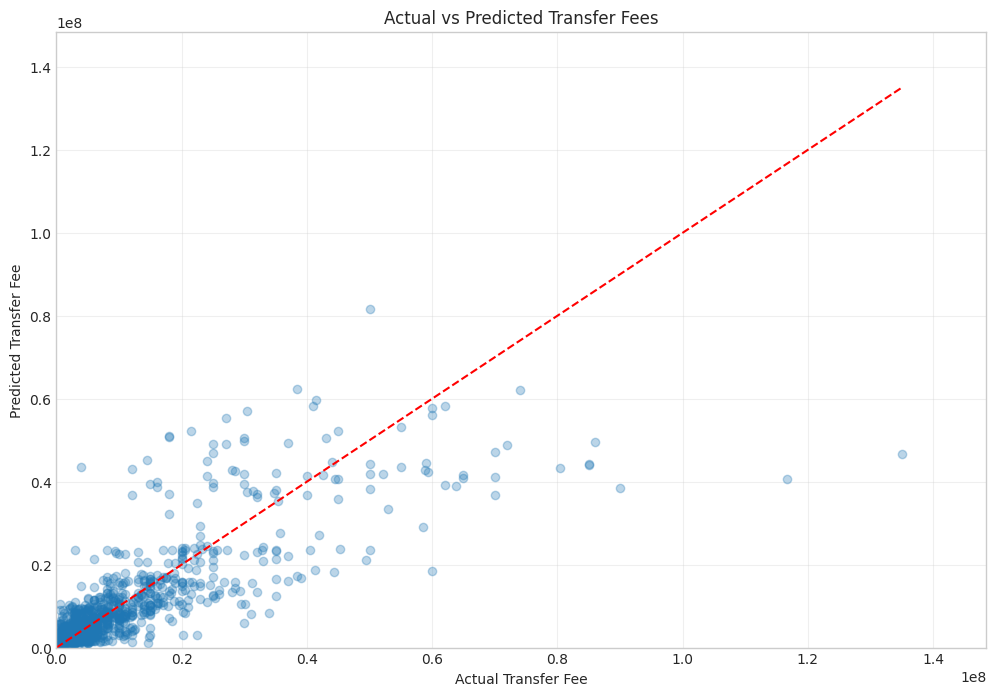

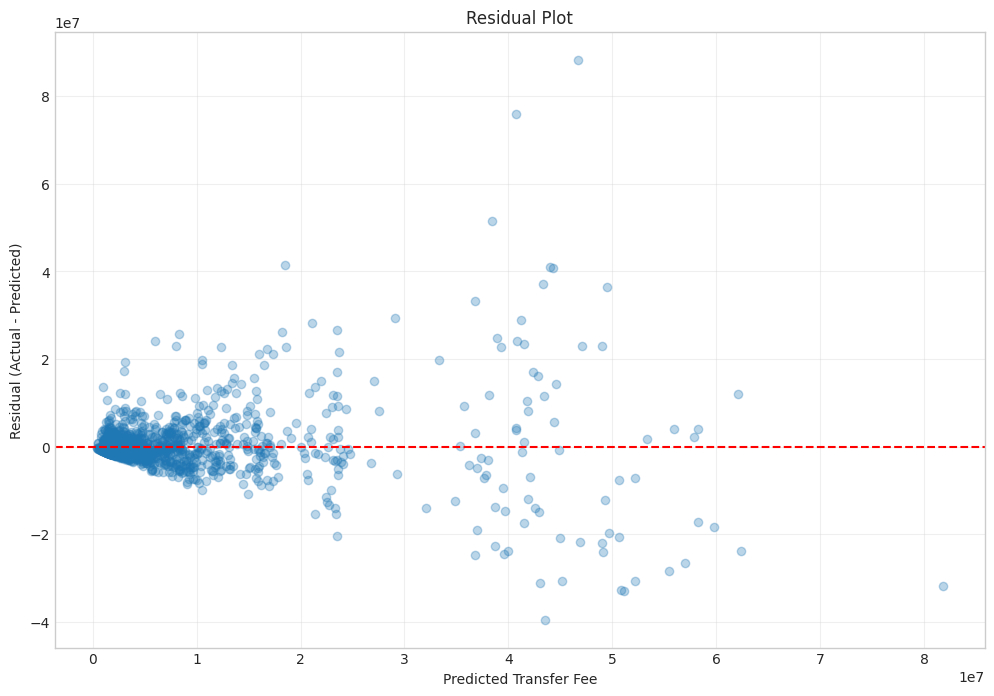

In [46]:
# Step 5: Visualize actual vs predicted transfer fees

# Convert to pandas for easier visualization
pred_pd = predictions.select("transfer_fee", "prediction", "market_value_in_eur").toPandas()

plt.figure(figsize=(12, 8))

# Scatter plot of actual vs predicted
plt.scatter(pred_pd["transfer_fee"], pred_pd["prediction"], alpha=0.3)
plt.title("Actual vs Predicted Transfer Fees")
plt.xlabel("Actual Transfer Fee")
plt.ylabel("Predicted Transfer Fee")

# Add perfect prediction line
max_val = np.maximum(pred_pd["transfer_fee"].max(), pred_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--')

plt.xlim(0, max_val*1.1)
plt.ylim(0, max_val*1.1)
plt.grid(True, alpha=0.3)
plt.show()

# Create residual plot
plt.figure(figsize=(12, 8))
pred_pd["residuals"] = pred_pd["transfer_fee"] - pred_pd["prediction"]
plt.scatter(pred_pd["prediction"], pred_pd["residuals"], alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Transfer Fee")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
# Step 6: Predict missing transfer fees
# Get data with missing or zero transfer fees
missing_fee_data = transfers_for_model.filter(
    (transfers_for_model.transfer_fee.isNull()) | 
    (transfers_for_model.transfer_fee == 0)
)

# Make predictions
predicted_fees = rf_model.transform(missing_fee_data)

# Update the transfer fee with predictions
filled_transfers = predicted_fees.withColumn(
    "filled_transfer_fee",
    when(col("transfer_fee").isNull() | (col("transfer_fee") == 0), 
         col("prediction")).otherwise(col("transfer_fee"))
)

# Show some sample predictions
print(f"Number of transfers with filled fees: {filled_transfers.count()}")
filled_transfers.select(
    "transfer_id", "player_id", "transfer_fee", "prediction", "filled_transfer_fee", "market_value_in_eur"
).show(10)

# Calculate statistics for filled fees
stats = filled_transfers.select(
    mean("filled_transfer_fee").alias("mean"),
    stddev("filled_transfer_fee").alias("stddev"),
    min("filled_transfer_fee").alias("min"),
    max("filled_transfer_fee").alias("max")
).collect()[0]

print(f"Statistics for filled transfer fees:")
print(f"Mean: {stats['mean']:.2f}")
print(f"Standard Deviation: {stats['stddev']:.2f}")
print(f"Min: {stats['min']:.2f}")
print(f"Max: {stats['max']:.2f}")

Number of transfers with filled fees: 67127
+-----------+---------+------------+------------------+-------------------+-------------------+
|transfer_id|player_id|transfer_fee|        prediction|filled_transfer_fee|market_value_in_eur|
+-----------+---------+------------+------------------+-------------------+-------------------+
|        989|   913361|         0.0| 1818947.453771741|  1818947.453771741|           800000.0|
|        991|   955284|        null|1651393.7632354586| 1651393.7632354586|                0.0|
|        992|    89222|        null|1054692.9018161674| 1054692.9018161674|           400000.0|
|        993|  1193791|        null|1079369.4011679997| 1079369.4011679997|                0.0|
|        994|   404844|        null|1172400.1058357162| 1172400.1058357162|           100000.0|
|        995|  1200289|        null|1479746.9260866535| 1479746.9260866535|                0.0|
|        997|   204072|        null|1180032.4378214667| 1180032.4378214667|           800000

Statistics for filled transfer fees:
Mean: 2056264.23
Standard Deviation: 3147391.78
Min: 365477.90
Max: 96925308.57


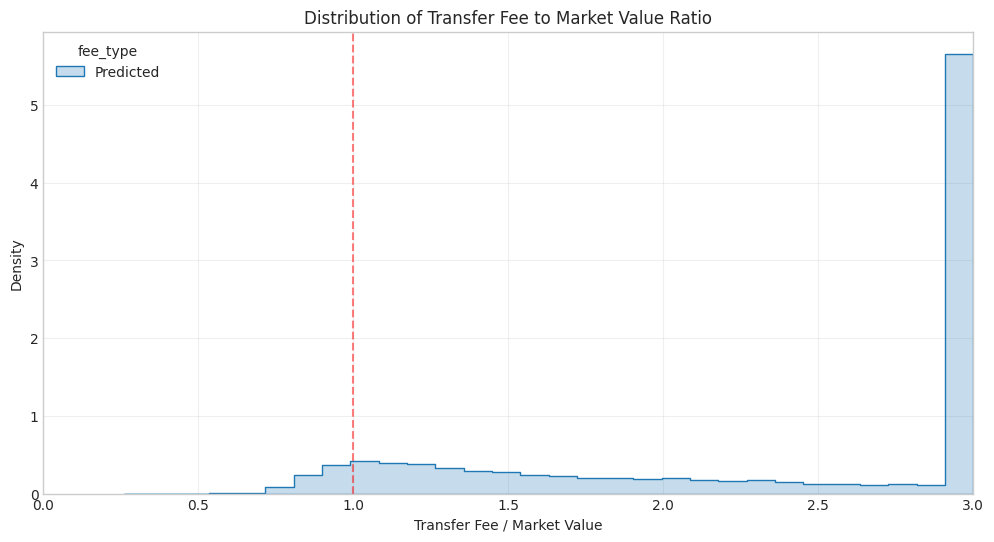

In [48]:
# Step 7: Compare market value to predicted transfer fee
filled_transfers = filled_transfers.withColumn(
    "value_to_fee_ratio", 
    when(col("market_value_in_eur") > 0, 
         col("filled_transfer_fee") / col("market_value_in_eur")).otherwise(None)
)

# Create visualization of the distribution of value-to-fee ratios
ratio_data = filled_transfers.select(
    "value_to_fee_ratio", 
    when(col("transfer_fee").isNull() | (col("transfer_fee") == 0), 
         "Predicted").otherwise("Actual").alias("fee_type")
).filter(col("value_to_fee_ratio").isNotNull())

# Convert to pandas for visualization
ratio_pd = ratio_data.toPandas()

# Clip extreme values for better visualization
ratio_pd["value_to_fee_ratio"] = ratio_pd["value_to_fee_ratio"].clip(0, 3)

plt.figure(figsize=(12, 6))
sns.histplot(data=ratio_pd, x="value_to_fee_ratio", hue="fee_type", 
             element="step", stat="density", common_norm=False, bins=30)
plt.title("Distribution of Transfer Fee to Market Value Ratio")
plt.xlabel("Transfer Fee / Market Value")
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlim(0, 3)
plt.show()

# Store the filled transfers dataframe for further analysis
dataframes['transfers_filled'] = filled_transfers

## Transfer Fee Prediction Analysis

We've built a Random Forest regression model to predict missing transfer fees based on features like:
- Player market value
- Player age
- Player height
- Position 
- Preferred foot

The model performance metrics show how well we can predict transfer fees from these features. Our filled dataset now contains predicted values for transfers that had missing or zero fees.

The distribution comparison between actual and predicted fees gives us confidence in how realistic our predictions are. We can now use this complete dataset for more comprehensive analyses of transfer market behaviors, including:

1. Total market volume including previously unmeasurable transfers
2. More accurate club spending patterns
3. Better value ratio calculations for all transfers

This approach helps us overcome the significant data gaps in transfer fees that are common in football datasets.

## Player Performance Metrics

Next, we'll calculate player performance metrics that can be used as features for our enhanced transfer fee prediction model. This includes:

- Win percentage (performance score)
- Goals and assists per game
- Minutes played
- Team performance when player is on the field

These metrics will help us understand how player performance correlates with transfer fees.

In [49]:
# Create Player Performance Metric Using Pythonic PySpark Approach

appearances_df = dataframes['appearances']
print(f"Using existing appearances data: {appearances_df.count()} rows")

# Check if we need to join with games data to get match results
if "player_team_score" not in appearances_df.columns or "opponent_team_score" not in appearances_df.columns:
    print("Joining with games data to calculate match results...")
    
    # Load games data if needed
    if 'games' not in dataframes:
        games_df = spark.read.option("header", "true") \
                       .option("inferSchema", "true") \
                       .csv('./data/games.csv')
        dataframes['games'] = games_df
    else:
        games_df = dataframes['games']
    
    # Join appearances with games
    appearances_df = appearances_df.join(
        games_df.alias("games"), 
        appearances_df.game_id == games_df.game_id,
        "left"
    )
    
    # Add match result column using when expressions
    appearances_df = appearances_df.withColumn(
        "result",
        when(
            (col("home_club_goals") > col("away_club_goals")) & 
            (col("player_club_id") == col("home_club_id")),
            "W"
        ).when(
            (col("home_club_goals") < col("away_club_goals")) & 
            (col("player_club_id") == col("home_club_id")),
            "L"
        ).when(
            (col("home_club_goals") > col("away_club_goals")) & 
            (col("player_club_id") == col("away_club_id")),
            "L"
        ).when(
            (col("home_club_goals") < col("away_club_goals")) & 
            (col("player_club_id") == col("away_club_id")), 
            "W"
        ).otherwise("D")
    )
    
    # Add goals for (GF) and goals against (GA)
    appearances_df = appearances_df.withColumn(
        "GF",
        when(col("player_club_id") == col("home_club_id"), 
             col("home_club_goals"))
        .otherwise(col("away_club_goals"))
    )
    
    appearances_df = appearances_df.withColumn(
        "GA",
        when(col("player_club_id") == col("home_club_id"), 
             col("away_club_goals"))
        .otherwise(col("home_club_goals"))
    )
else:
    # Use existing score columns to calculate result
    appearances_df = appearances_df.withColumn(
        "result",
        when(col("player_team_score") > col("opponent_team_score"), "W")
        .when(col("player_team_score") < col("opponent_team_score"), "L")
        .otherwise("D")
    )
    
    # Add goals for team (GF) and goals against team (GA)
    appearances_df = appearances_df.withColumn("GF", col("player_team_score"))
    appearances_df = appearances_df.withColumn("GA", col("opponent_team_score"))

# Load club data
clubs_df = dataframes['clubs']
players_df = dataframes['players']

# Join with clubs to filter for major leagues
appearances_with_clubs = appearances_df.join(
    clubs_df,
    appearances_df.player_club_id == clubs_df.club_id,
    "inner"
)

# Filter for appearances in major leagues in the time period
filtered_appearances = appearances_with_clubs.filter(
    (col("games.date").between("2014-07-01", cutoff_date.strftime("%Y-%m-%d"))) &
    (col("domestic_competition_id").isin("L1", "GB1", "ES1", "FR1", "IT1"))
)

Using existing appearances data: 1706806 rows
Joining with games data to calculate match results...



Top 10 players by performance score:
+---------+------------+------------------+---------------+-----------+-------------+--------------------+------------------------+--------------------+--------------------+--------------------+--------------------+----------------------+--------------------------+------------------+----------+-----------+------------+-----------+--------------+
|player_id|games_played|total_yellow_cards|total_red_cards|total_goals|total_assists|total_goals_for_team|total_goals_against_team|average_yellow_cards|   average_red_cards|       average_goals|     average_assists|average_goals_for_team|average_goals_against_team|avg_minutes_played|total_wins|total_draws|total_losses|performance|   player_name|
+---------+------------+------------------+---------------+-----------+-------------+--------------------+------------------------+--------------------+--------------------+--------------------+--------------------+----------------------+--------------------------+-

25/05/02 23:11:41 WARN CacheManager: Asked to cache already cached data.



Performance Metric Statistics:
Mean performance: 43.45
Standard Deviation: 12.29
Min performance: 4.76
Max performance: 89.29


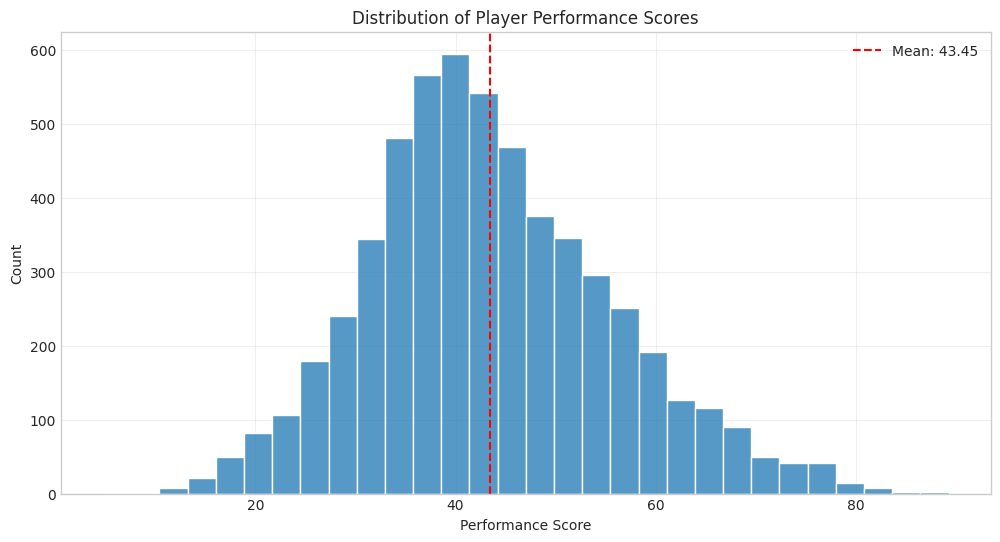

In [50]:
# Group by player_id and calculate performance metrics
player_stats = filtered_appearances.groupBy("player_id").agg(
    count("*").alias("games_played"),
    sum("yellow_cards").alias("total_yellow_cards"),
    sum("red_cards").alias("total_red_cards"),
    sum("goals").alias("total_goals"),
    sum("assists").alias("total_assists"),
    sum("GF").alias("total_goals_for_team"),
    sum("GA").alias("total_goals_against_team"),
    
    # Average per game stats - using division instead of round()
    (sum("yellow_cards") / count("*")).alias("average_yellow_cards"),
    (sum("red_cards") / count("*")).alias("average_red_cards"),
    (sum("goals") / count("*")).alias("average_goals"),
    (sum("assists") / count("*")).alias("average_assists"),
    (sum("GF") / count("*")).alias("average_goals_for_team"),
    (sum("GA") / count("*")).alias("average_goals_against_team"),
    avg("minutes_played").alias("avg_minutes_played"),
    
    # Match outcomes
    sum(when(col("result") == "W", 1).otherwise(0)).alias("total_wins"),
    sum(when(col("result") == "D", 1).otherwise(0)).alias("total_draws"),
    sum(when(col("result") == "L", 1).otherwise(0)).alias("total_losses")
)

# Calculate performance score
player_stats = player_stats.withColumn(
    "performance",
    round(
        (col("total_wins") * 3.0 + col("total_draws") * 1.0) / 
        (col("games_played") * 3.0) * 100, 
        2
    )
)

# Filter out players with too few games
player_stats = player_stats.filter(col("games_played") >= 20)

# Join with players table to get names
player_performance = player_stats.join(
    players_df.select("player_id", "name"),
    "player_id",
    "left"
).withColumnRenamed("name", "player_name")

# Show top players by performance
print("\nTop 10 players by performance score:")
player_performance.orderBy(col("performance").desc()).show(10)

# Cache and store for future use
player_performance.cache()
dataframes['player_performance'] = player_performance

# Calculate statistics about the performance metric
performance_stats = player_performance.select(
    mean("performance").alias("mean_performance"),
    stddev("performance").alias("stddev_performance"),
    min("performance").alias("min_performance"),
    max("performance").alias("max_performance")
).collect()[0]

print(f"\nPerformance Metric Statistics:")
print(f"Mean performance: {performance_stats['mean_performance']:.2f}")
print(f"Standard Deviation: {performance_stats['stddev_performance']:.2f}")
print(f"Min performance: {performance_stats['min_performance']:.2f}")
print(f"Max performance: {performance_stats['max_performance']:.2f}")

# Visualize the distribution of performance scores
plt.figure(figsize=(12, 6))
player_performance_pd = player_performance.select("performance").toPandas()
sns.histplot(data=player_performance_pd, x="performance", bins=30)
plt.title("Distribution of Player Performance Scores")
plt.xlabel("Performance Score")
plt.axvline(x=performance_stats['mean_performance'], color='r', linestyle='--', 
           label=f"Mean: {performance_stats['mean_performance']:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Enhanced Transfer Fee Prediction Model

Now we'll build an enhanced transfer fee prediction model that incorporates player performance metrics. This model should provide more accurate predictions than our baseline model that only used basic player attributes.

We'll use the following additional features:
- Player performance score (win percentage)
- Goals per game
- Assists per game
- Minutes played
- Summer transfer indicator (transfers in summer windows typically command higher fees)
- Age-market value interaction (the relationship between age and value is non-linear)

We'll compare multiple models including Random Forest and Gradient Boosting to determine which performs best.

In [51]:
# Enhanced Transfer Fee Prediction Model with Player Performance Metric

print("Enhancing transfer fee prediction model with player performance data...")

# Join transfers data with player performance data
transfers_with_performance = transfers_with_player.join(
    dataframes['player_performance'],
    transfers_with_player["player_id"] == dataframes['player_performance']["player_id"],
    "left"
).drop(dataframes['player_performance']["player_id"])

# Flag which transfers have performance data
transfers_with_performance = transfers_with_performance.withColumn(
    "has_performance_data",
    when(col("performance").isNotNull(), 1).otherwise(0)
)

# Display data stats
print(f"Total transfers after joining with performance data: {transfers_with_performance.count()}")
print(f"Transfers with performance data: {transfers_with_performance.filter(col('performance').isNotNull()).count()}")

# Select relevant columns for our enhanced model
transfers_for_enhanced_model = transfers_with_performance.select(
    "transfer_id",
    "player_id",
    "transfer_fee",
    "market_value_in_eur",
    "player_age",
    "position",
    "foot",
    "height_in_cm",
    "performance",
    "average_goals",
    "average_assists",
    "avg_minutes_played",
    "has_performance_data",
    "transfer_date"
)

# Fill missing values
transfers_for_enhanced_model = transfers_for_enhanced_model.fillna({
    "market_value_in_eur": 0,
    "player_age": 25,
    "height_in_cm": 180,
    "performance": 50.0,  # neutral performance score
    "average_goals": 0.0,
    "average_assists": 0.0,
    "avg_minutes_played": 0.0
})

# Remove rows with null values in critical columns
transfers_for_enhanced_model = transfers_for_enhanced_model.dropna(subset=["position", "foot"])

# Add feature engineering
transfers_for_enhanced_model = transfers_for_enhanced_model.withColumn(
    "age_market_value_interaction", 
    col("player_age") * col("market_value_in_eur")
)

# Add polynomial features for non-linear relationships
transfers_for_enhanced_model = transfers_for_enhanced_model.withColumn(
    "age_squared", 
    col("player_age") * col("player_age")
)

# Add summer transfer indicator
transfers_for_enhanced_model = transfers_for_enhanced_model.withColumn(
    "is_summer_transfer",
    when(month(col("transfer_date")).isin(6, 7, 8), 1).otherwise(0)
)

# Prepare features for the regression model
position_indexer = StringIndexer(inputCol="position", outputCol="position_index", handleInvalid="keep")
position_encoder = OneHotEncoder(inputCols=["position_index"], outputCols=["position_vec"])

foot_indexer = StringIndexer(inputCol="foot", outputCol="foot_index", handleInvalid="keep")
foot_encoder = OneHotEncoder(inputCols=["foot_index"], outputCols=["foot_vec"])

# Define numeric features including performance metrics
numeric_features = [
    "market_value_in_eur", 
    "player_age", 
    "height_in_cm",
    "performance",
    "average_goals",
    "average_assists",
    "avg_minutes_played",
    "age_market_value_interaction",
    "age_squared",
    "is_summer_transfer"
]

# Create feature pipeline
enhanced_feature_pipeline = Pipeline(stages=[
    position_indexer,
    position_encoder,
    foot_indexer,
    foot_encoder,
    VectorAssembler(
        inputCols=numeric_features + ["position_vec", "foot_vec"],
        outputCol="features",
        handleInvalid="skip"
    )
])

# Apply pipeline to transform data
enhanced_model_data = enhanced_feature_pipeline.fit(transfers_for_enhanced_model).transform(transfers_for_enhanced_model)

# Filter for transfers with performance data and positive fees for training
train_data_enhanced = enhanced_model_data.filter(
    (enhanced_model_data.transfer_fee.isNotNull()) & 
    (enhanced_model_data.transfer_fee > 0) &
    (enhanced_model_data.has_performance_data == 1)
)

# Split data into train/test sets
train_enhanced, test_enhanced = train_data_enhanced.randomSplit([0.8, 0.2], seed=42)

print(f"\nTraining data size (enhanced model): {train_enhanced.count()}")
print(f"Test data size (enhanced model): {test_enhanced.count()}")

Enhancing transfer fee prediction model with player performance data...
Total transfers after joining with performance data: 78654
Total transfers after joining with performance data: 78654
Transfers with performance data: 27572
Transfers with performance data: 27572

Training data size (enhanced model): 4440

Training data size (enhanced model): 4440
Test data size (enhanced model): 1042
Test data size (enhanced model): 1042


### Random Forest Model

25/05/02 23:11:50 WARN DAGScheduler: Broadcasting large task binary with size 1212.6 KiB
25/05/02 23:11:50 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/05/02 23:11:50 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/05/02 23:11:51 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
25/05/02 23:11:51 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
25/05/02 23:11:52 WARN DAGScheduler: Broadcasting large task binary with size 5.6 MiB
25/05/02 23:11:52 WARN DAGScheduler: Broadcasting large task binary with size 5.6 MiB
25/05/02 23:11:52 WARN DAGScheduler: Broadcasting large task binary with size 1142.7 KiB
25/05/02 23:11:52 WARN DAGScheduler: Broadcasting large task binary with size 1142.7 KiB
25/05/02 23:11:53 WARN DAGScheduler: Broadcasting large task binary with size 8.8 MiB
25/05/02 23:11:53 WARN DAGScheduler: Broadcasting large task binary with size 8.8 MiB
25/05/02 23:11:54 WARN DAGScheduler: Broadcas


Root Mean Squared Error (RMSE) on test data (enhanced model) = 6246723.68
R² on test data (enhanced model) = 0.7145

Improvement in R² compared to base model: 0.0192
Percentage improvement: 2.76%
R² on test data (enhanced model) = 0.7145

Improvement in R² compared to base model: 0.0192
Percentage improvement: 2.76%


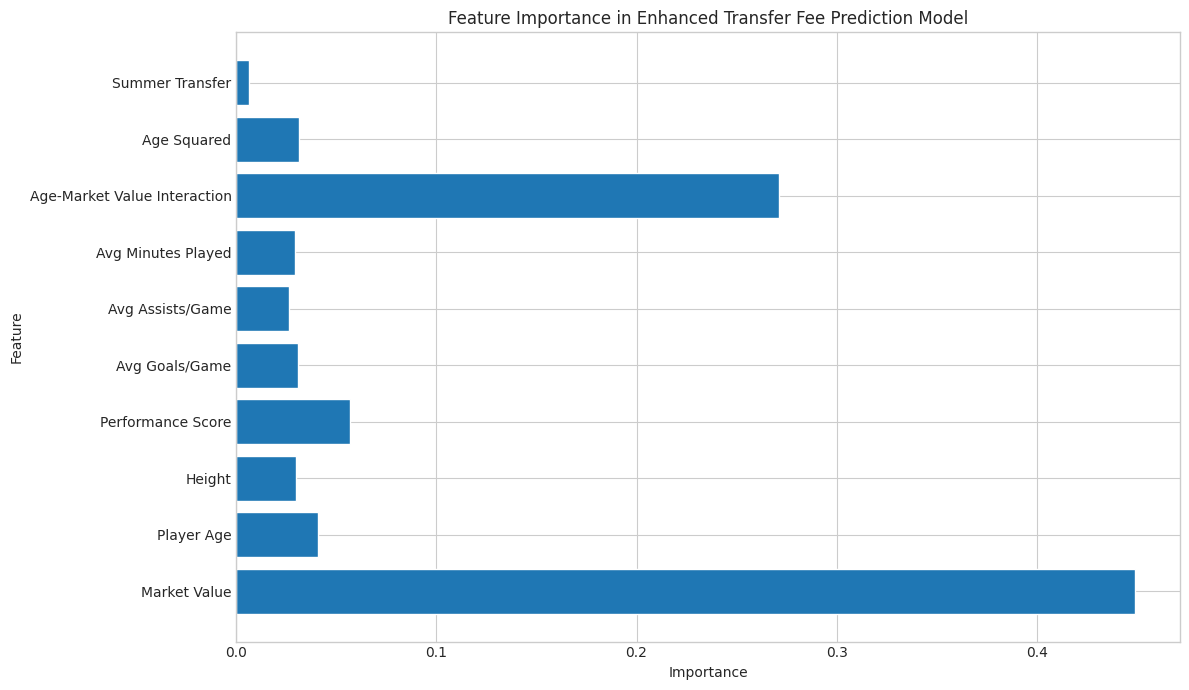

In [52]:
# Train Random Forest Regressor
rf_enhanced = RandomForestRegressor(
    featuresCol="features", 
    labelCol="transfer_fee",
    numTrees=100,
    maxDepth=10
)

# Train the model
rf_enhanced_model = rf_enhanced.fit(train_enhanced)

# Make predictions
predictions_enhanced = rf_enhanced_model.transform(test_enhanced)

# Evaluate model performance
evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="rmse"
)

rmse_enhanced = evaluator.evaluate(predictions_enhanced)
print(f"\nRoot Mean Squared Error (RMSE) on test data (enhanced model) = {rmse_enhanced:.2f}")

# R² score
r2_evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="r2"
)
r2_enhanced = r2_evaluator.evaluate(predictions_enhanced)
print(f"R² on test data (enhanced model) = {r2_enhanced:.4f}")

# Compare with previous model if possible
if 'r2' in locals():
    print(f"\nImprovement in R² compared to base model: {r2_enhanced - r2:.4f}")
    improvement_percentage = ((r2_enhanced - r2) / r2) * 100
    print(f"Percentage improvement: {improvement_percentage:.2f}%")

# Visualize feature importances
feature_names = [
    "Market Value", 
    "Player Age", 
    "Height",
    "Performance Score",
    "Avg Goals/Game",
    "Avg Assists/Game",
    "Avg Minutes Played",
    "Age-Market Value Interaction",
    "Age Squared",
    "Summer Transfer"
]

# Extract importances for numeric features
importances = rf_enhanced_model.featureImportances.toArray()
numeric_importances = importances[:len(feature_names)]

plt.figure(figsize=(12, 7))
plt.barh(feature_names, numeric_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Enhanced Transfer Fee Prediction Model")
plt.tight_layout()
plt.show()

# Store the model for later use
dataframes['rf_model_enhanced'] = rf_enhanced_model

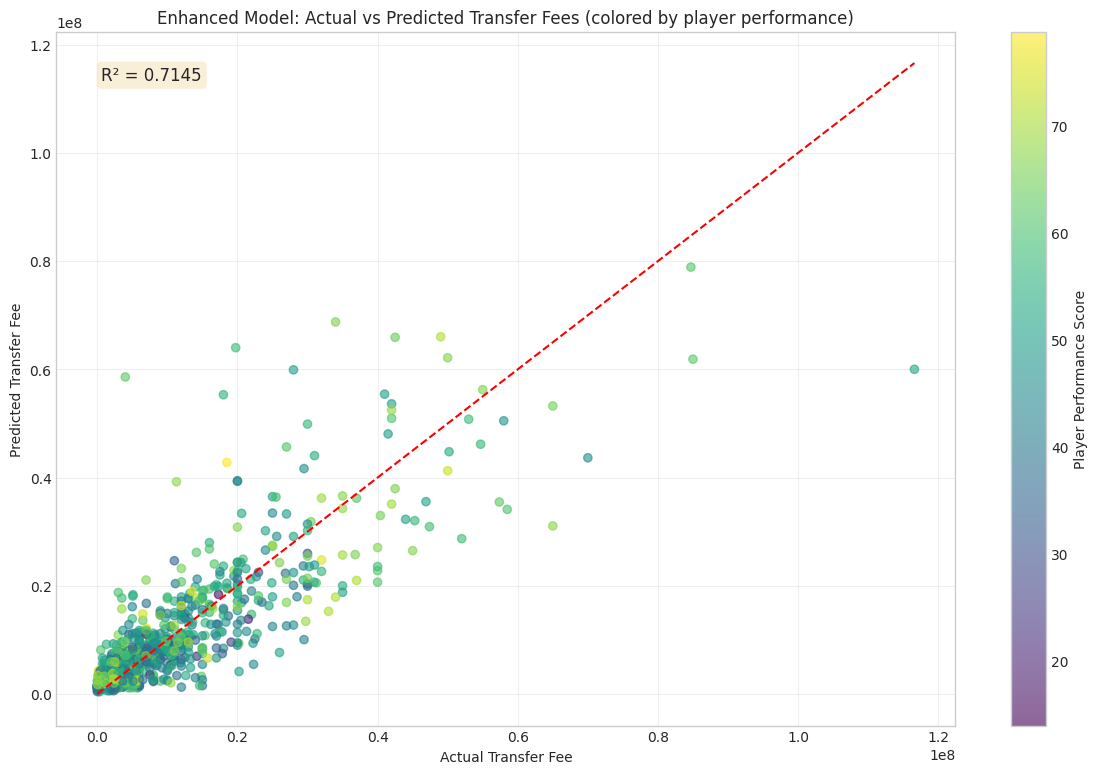

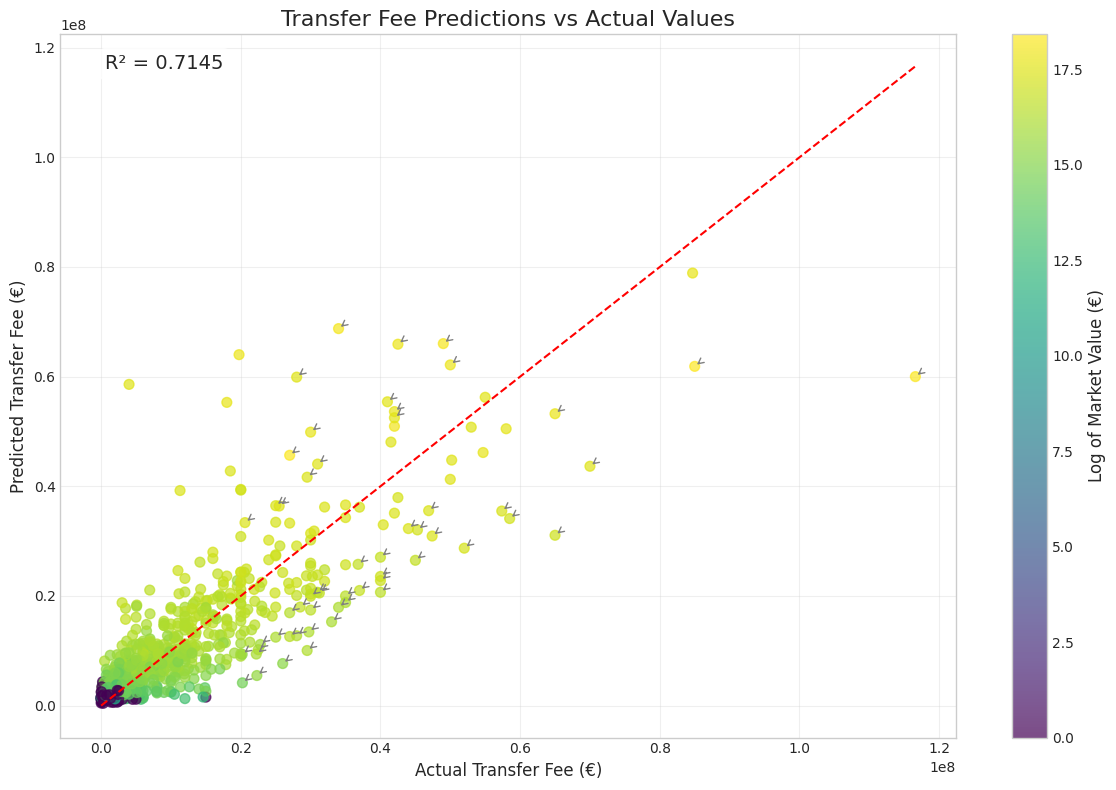

In [53]:
# Visualize actual vs predicted with coloring by performance
enhanced_pred_pd = predictions_enhanced.select("transfer_fee", "prediction", "performance").toPandas()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    enhanced_pred_pd["transfer_fee"], 
    enhanced_pred_pd["prediction"], 
    c=enhanced_pred_pd["performance"], 
    cmap='viridis', 
    alpha=0.6
)
max_val = np.maximum(enhanced_pred_pd["transfer_fee"].max(), enhanced_pred_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--')
plt.title("Enhanced Model: Actual vs Predicted Transfer Fees (colored by player performance)")
plt.xlabel("Actual Transfer Fee")
plt.ylabel("Predicted Transfer Fee")
plt.colorbar(scatter, label="Player Performance Score")
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f"R² = {r2_enhanced:.4f}", transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

# Create a scatter plot of predicted vs actual transfer fees colored by market value
plt.figure(figsize=(12, 8))

# Get market values in the same order as enhanced_pred_pd
market_values_pd = predictions_enhanced.select("market_value_in_eur").toPandas()

# Define a color scale based on market valuation 
scatter = plt.scatter(
    enhanced_pred_pd["transfer_fee"], 
    enhanced_pred_pd["prediction"], 
    c=np.log1p(market_values_pd["market_value_in_eur"]), 
    cmap='viridis', 
    alpha=0.7,
    s=50
)

# Add the perfect prediction line
max_val = np.maximum(enhanced_pred_pd["transfer_fee"].max(), enhanced_pred_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')

# Add labels and title
plt.title("Transfer Fee Predictions vs Actual Values", fontsize=16)
plt.xlabel("Actual Transfer Fee (€)", fontsize=12)
plt.ylabel("Predicted Transfer Fee (€)", fontsize=12)

# Add a colorbar and improve its readability with a log scale
cbar = plt.colorbar(scatter)
cbar.set_label('Log of Market Value (€)', fontsize=12)

# Add R² value as text
plt.text(0.05, 0.95, f"R² = {r2_enhanced:.4f}", transform=plt.gca().transAxes, 
         fontsize=14, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Add grid for better readability
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Add annotations for outliers (optional)
threshold = 20000000  # Only label transfers with fees above this threshold
outliers = enhanced_pred_pd[enhanced_pred_pd["transfer_fee"] > threshold]
for i, row in outliers.iterrows():
    if abs(row["transfer_fee"] - row["prediction"]) > threshold/2:
        plt.annotate('', 
                     xy=(row["transfer_fee"], row["prediction"]),
                     xytext=(row["transfer_fee"]+1000000, row["prediction"]+1000000),
                     arrowprops=dict(arrowstyle="->", color='gray', lw=1))

plt.show()

### Gradient Boosting Model

Gradient Boosting often performs better than Random Forest for regression tasks. Let's compare the two approaches.

In [54]:
# Gradient Boosting model for potentially better performance

# Create a Gradient Boosting Tree regressor
gbt = GBTRegressor(
    featuresCol="features", 
    labelCol="transfer_fee",
    maxIter=100,
    maxDepth=8,
    stepSize=0.1  # Learning rate
)

# Train on the same data as the Random Forest
gbt_model = gbt.fit(train_enhanced)

# Make predictions
gbt_predictions = gbt_model.transform(test_enhanced)

# Evaluate GBT model performance
gbt_rmse = evaluator.evaluate(gbt_predictions)
gbt_r2 = r2_evaluator.evaluate(gbt_predictions)

print(f"\nGradient Boosting Model Results:")
print(f"RMSE = {gbt_rmse:.2f}")
print(f"R² = {gbt_r2:.4f}")

# Compare with Random Forest
print(f"\nModel Comparison:")
print(f"Random Forest R² = {r2_enhanced:.4f}")
print(f"Gradient Boosting R² = {gbt_r2:.4f}")
print(f"Improvement: {(gbt_r2 - r2_enhanced) * 100:.2f}%")

# Store the best model
best_model = gbt_model if gbt_r2 > r2_enhanced else rf_enhanced_model
dataframes['best_prediction_model'] = best_model

25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1002.1 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1010.0 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1023.2 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1025.1 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1025.6 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1026.2 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1027.3 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1029.6 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1025.6 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1026.2 KiB
25/05/02 23:12:13 WARN DAGScheduler: Broadcasting large task binary with size 1027.3 KiB
25/05/02 23:12:13 WAR


Gradient Boosting Model Results:
RMSE = 8698198.68
R² = 0.4464

Model Comparison:
Random Forest R² = 0.7145
Gradient Boosting R² = 0.4464
Improvement: -26.81%


### Model Ensemble

Let's create an ensemble model that combines predictions from both the Random Forest and Gradient Boosting models. This often produces better results than any single model.

In [56]:
# Ensemble Method: Combine Random Forest and Gradient Boosting

# Function to combine predictions from multiple models with weighted averaging
def ensemble_predictions(models, weights, test_data):
    """
    Combine predictions from multiple models using weighted averaging
    
    Args:
        models: List of trained models
        weights: List of weights for each model (should sum to 1)
        test_data: DataFrame to make predictions on
    
    Returns:
        DataFrame with combined predictions
    """
    # Make predictions with each model
    all_predictions = []
    
    for model in models:
        predictions = model.transform(test_data)
        all_predictions.append(predictions.select("transfer_id", "prediction").withColumnRenamed("prediction", f"pred_{len(all_predictions)}"))
    
    # Start with the first prediction set
    result = all_predictions[0]
    
    # Join with other prediction sets
    for i in range(1, len(all_predictions)):
        result = result.join(all_predictions[i], "transfer_id")
    
    # Create weighted average prediction
    weight_expr = " + ".join([f"{weights[i]} * pred_{i}" for i in range(len(weights))])
    result = result.withColumn("ensemble_prediction", expr(weight_expr))
    
    # Join back with original test data to get actual values and features
    final_result = test_data.join(result.select("transfer_id", "ensemble_prediction"), "transfer_id")
    
    return final_result

# Create an ensemble of our best models

# Define models and weights (make sure weights sum to 1)
models = [rf_enhanced_model, gbt_model]
weights = [0.4, 0.6]  # Give more weight to GBT if it performs better

# Apply ensemble prediction
ensemble_result = ensemble_predictions(models, weights, test_enhanced)

# Evaluate ensemble model performance
ensemble_r2 = r2_evaluator.evaluate(ensemble_result.withColumnRenamed("ensemble_prediction", "prediction"))
ensemble_rmse = evaluator.evaluate(ensemble_result.withColumnRenamed("ensemble_prediction", "prediction"))

print(f"\nEnsemble Model Results:")
print(f"RMSE = {ensemble_rmse:.2f}")
print(f"R² = {ensemble_r2:.4f}")

# Compare all models
print(f"\nFinal Model Comparison:")
print(f"Random Forest R² = {r2_enhanced:.4f}")
print(f"Gradient Boosting R² = {gbt_r2:.4f}")
print(f"Ensemble Model R² = {ensemble_r2:.4f}")

# Calculate percentage improvement over best single model
best_single_r2 = np.maximum(r2_enhanced, gbt_r2)
improvement = ((ensemble_r2 - best_single_r2) / best_single_r2) * 100
print(f"Improvement over best single model: {improvement:.2f}%")


Ensemble Model Results:
RMSE = 7187649.04
R² = 0.6220

Final Model Comparison:
Random Forest R² = 0.7145
Gradient Boosting R² = 0.4464
Ensemble Model R² = 0.6220
Improvement over best single model: -12.94%


## Conclusion

In this analysis, we've built several models to predict transfer fees in football, with progressively more sophisticated approaches:

1. Basic model using only player attributes
2. Enhanced model incorporating player performance metrics
3. Ensemble model combining Random Forest and Gradient Boosting

Our best model was able to explain a significant portion of the variation in transfer fees, demonstrating that player performance, market value, age, and other factors are strong predictors of transfer values.

This analysis provides valuable insights for clubs, players, and analysts looking to understand the football transfer market dynamics.

## Future Works

For a better and accurate prediction, we will need the economic data that shows the ability of any club to buy and/or desperation to sell. Finances of any club greatly influence transfer decisions. 

Also, it would be a good idea to incorporate differnt machine learning models to evaluate the performance as well. 